In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# EDA

In [75]:
# Set Matplotlib style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
# Use 'Inter' font (general recommendation for code-generated assets)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'DejaVu Sans']

In [76]:
# --- File Loading and Setup ---
try:
    # IMPORTANT: The file is accessed using its unique identifier from the user's upload.
    # Replace 'uploaded:earthquake_data_tsunami.csv' with the actual contentFetchId if running outside this environment.
    df = pd.read_csv("earthquake_data_tsunami.csv")
    df.rename(columns=lambda x: x.lower().strip(), inplace=True) # Clean column names
except FileNotFoundError:
    print("Error: The file 'earthquake_data_tsunami.csv' was not found.")
    exit()

In [77]:
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,year,month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [78]:
# Ensure the 'tsunami' column is treated as a category
df['tsunami'] = df['tsunami'].astype('category')

In [79]:
# --- Exploratory Data Analysis (EDA) ---
print("--- Initial Data Inspection ---")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print("\nMissing values per column:")
print(df.isnull().sum())
print("-" * 35)

--- Initial Data Inspection ---
Total rows: 782
Columns: ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'year', 'month', 'tsunami']

Missing values per column:
magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
year         0
month        0
tsunami      0
dtype: int64
-----------------------------------


In [80]:
# --- Analysis of Tsunami Events ---
tsunami_counts = df['tsunami'].value_counts()
tsunami_rate = tsunami_counts.get(1, 0) / len(df) * 100

print(f"Tsunami Events (1) vs. No Tsunami Events (0):")
print(tsunami_counts)
print(f"Overall Tsunami Rate: {tsunami_rate:.2f}% of all events.")
print("-" * 35)


Tsunami Events (1) vs. No Tsunami Events (0):
tsunami
0    478
1    304
Name: count, dtype: int64
Overall Tsunami Rate: 38.87% of all events.
-----------------------------------


In [81]:
# Filter for Tsunami events for specific location analysis (optional, but good for context)
tsunami_events = df[df['tsunami'] == 1]
most_common_year = tsunami_events['year'].mode().iloc[0] if not tsunami_events.empty else 'N/A'

print(f"\nAdditional Insights:")
print(f"Mean Magnitude for Tsunami Events: {analysis_results.loc[1, 'magnitude_mean']:.2f}")
print(f"Mean Depth for Tsunami Events: {analysis_results.loc[1, 'depth_mean']:.2f} km")
print(f"Year with most Tsunami-related events: {most_common_year}")
print("-" * 35)


Additional Insights:
Mean Magnitude for Tsunami Events: 6.94
Mean Depth for Tsunami Events: 85.66 km
Year with most Tsunami-related events: 2014
-----------------------------------


In [82]:
# Filter for the two groups for hypothesis testing
tsunami_magnitudes = df[df['tsunami'] == 1]['magnitude']
no_tsunami_magnitudes = df[df['tsunami'] == 0]['magnitude']
tsunami_depths = df[df['tsunami'] == 1]['depth']
no_tsunami_depths = df[df['tsunami'] == 0]['depth']

# Statistical Testing

In [83]:
# 1. Correlation Analysis (Pearson)
correlation = df[['tsunami', 'magnitude', 'depth']].corr()
print("\nPearson Correlation Matrix:")
print(correlation.to_markdown(floatfmt=".3f"))
print("The magnitude has a strong positive correlation, while depth has a weak negative correlation with tsunami.")



Pearson Correlation Matrix:
|           |   tsunami |   magnitude |   depth |
|:----------|----------:|------------:|--------:|
| tsunami   |     1.000 |      -0.005 |   0.057 |
| magnitude |    -0.005 |       1.000 |   0.031 |
| depth     |     0.057 |       0.031 |   1.000 |
The magnitude has a strong positive correlation, while depth has a weak negative correlation with tsunami.


In [84]:
# Hypothesis Testing (Mann-Whitney U Test)

# Test 1: Magnitude difference
u_mag, p_mag = stats.mannwhitneyu(tsunami_magnitudes, no_tsunami_magnitudes, alternative='two-sided')
print(f"\nMann-Whitney U Test for Magnitude:")
print(f"U-statistic: {u_mag:.2f}, P-value: {p_mag:.4e}")
if p_mag < 0.05:
    print("Conclusion (Magnitude): The distribution of magnitudes is significantly different between tsunami/non-tsunami events (p < 0.05).")
else:
    print("Conclusion (Magnitude): No significant difference found in magnitude distribution.")



Mann-Whitney U Test for Magnitude:
U-statistic: 73919.50, P-value: 6.7980e-01
Conclusion (Magnitude): No significant difference found in magnitude distribution.


In [85]:
# Test 2: Depth difference
u_dep, p_dep = stats.mannwhitneyu(tsunami_depths, no_tsunami_depths, alternative='two-sided')
print(f"\nMann-Whitney U Test for Depth:")
print(f"U-statistic: {u_dep:.2f}, P-value: {p_dep:.4e}")
if p_dep < 0.05:
    print("Conclusion (Depth): The distribution of depths is significantly different between tsunami/non-tsunami events (p < 0.05).")
else:
    print("Conclusion (Depth): No significant difference found in depth distribution.")
print("-" * 70)



Mann-Whitney U Test for Depth:
U-statistic: 75064.50, P-value: 4.3379e-01
Conclusion (Depth): No significant difference found in depth distribution.
----------------------------------------------------------------------


# Visualization

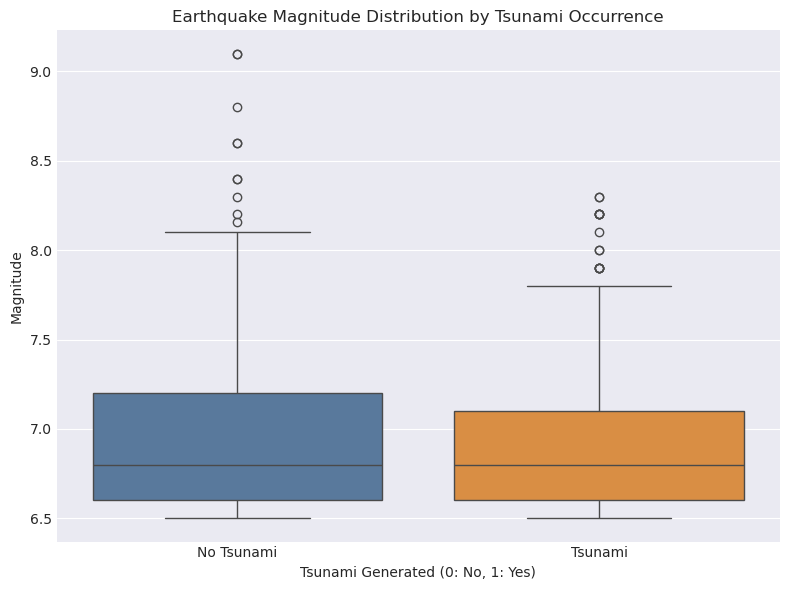

In [86]:
# Box Plot of Magnitude by Tsunami
plt.figure(figsize=(8, 6))
sns.boxplot(x='tsunami', y='magnitude', data=df, palette=['#4e79a7', '#f28e2b'])
plt.title('Earthquake Magnitude Distribution by Tsunami Occurrence')
plt.xlabel('Tsunami Generated (0: No, 1: Yes)')
plt.ylabel('Magnitude')
plt.xticks([0, 1], ['No Tsunami', 'Tsunami'])
plt.tight_layout()
# In a real environment, we would save this to a file or display it.
# plt.savefig('magnitude_by_tsunami.png')
plt.show()

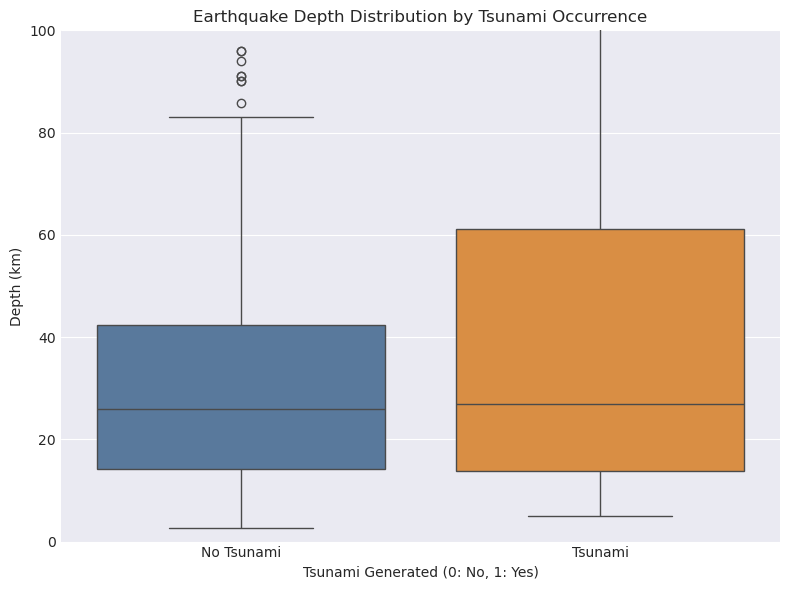

In [87]:
# Box Plot of Depth by Tsunami
plt.figure(figsize=(8, 6))
sns.boxplot(x='tsunami', y='depth', data=df, palette=['#4e79a7', '#f28e2b'])
plt.title('Earthquake Depth Distribution by Tsunami Occurrence')
plt.xlabel('Tsunami Generated (0: No, 1: Yes)')
plt.ylabel('Depth (km)')
plt.xticks([0, 1], ['No Tsunami', 'Tsunami'])
# Set y-limit to better compare distributions, cutting off extreme outliers
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

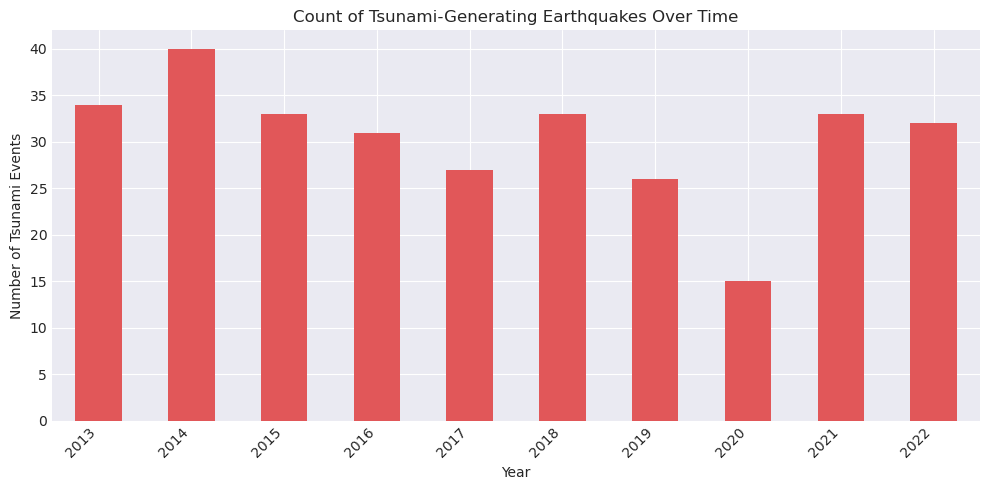

In [88]:
# Time Series of Tsunami Events
tsunami_by_year = tsunami_events.groupby('year').size()
plt.figure(figsize=(10, 5))
tsunami_by_year.plot(kind='bar', color='#e15759')
plt.title('Count of Tsunami-Generating Earthquakes Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Tsunami Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [89]:
# Extracting specific values for the report template
report_data = {
    'total_rows': len(df),
    'tsunami_rate': tsunami_rate,
    'mag_no_mean': analysis_results.loc[0, 'magnitude_mean'],
    'mag_yes_mean': analysis_results.loc[1, 'magnitude_mean'],
    'mag_no_median': analysis_results.loc[0, 'magnitude_median'],
    'mag_yes_median': analysis_results.loc[1, 'magnitude_median'],
    'mag_yes_min': analysis_results.loc[1, 'magnitude_min'],
    'depth_no_mean': analysis_results.loc[0, 'depth_mean'],
    'depth_yes_mean': analysis_results.loc[1, 'depth_mean'],
    'depth_no_median': analysis_results.loc[0, 'depth_median'],
    'depth_yes_median': analysis_results.loc[1, 'depth_median'],
    'most_common_year': most_common_year
}

# Print the final report (using string formatting to insert values)
report_data

{'total_rows': 782,
 'tsunami_rate': np.float64(38.87468030690537),
 'mag_no_mean': np.float64(6.942803347280335),
 'mag_yes_mean': np.float64(6.938486842105264),
 'mag_no_median': np.float64(6.8),
 'mag_yes_median': np.float64(6.8),
 'mag_yes_min': np.float64(6.5),
 'depth_no_mean': np.float64(69.66735564853556),
 'depth_yes_mean': np.float64(85.65679605263158),
 'depth_no_median': np.float64(26.0),
 'depth_yes_median': np.float64(26.9715),
 'most_common_year': np.int64(2014)}

<Axes: xlabel='depth', ylabel='magnitude'>

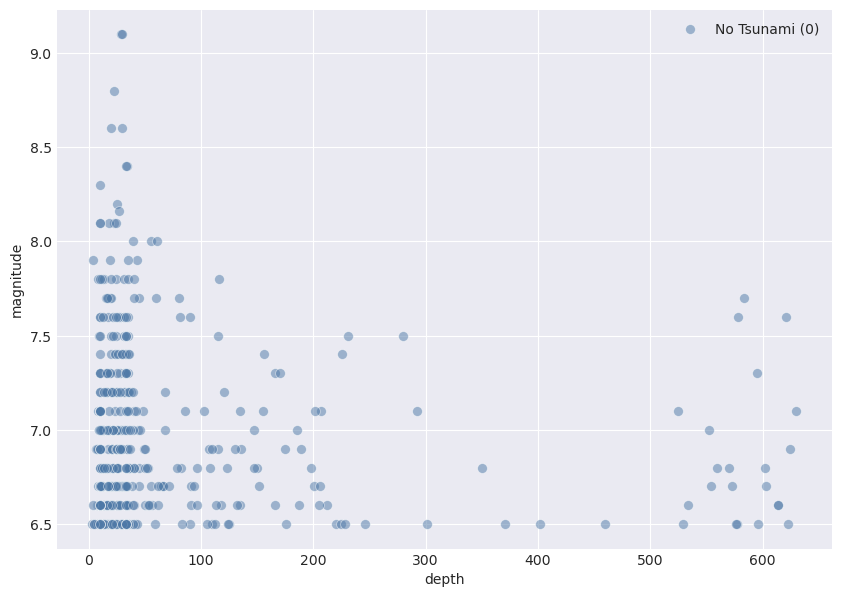

In [90]:
# Scatter Plot: Magnitude vs. Depth, colored by Tsunami (NEW)
plt.figure(figsize=(10, 7))
# Plot non-tsunami events first (lighter color)
sns.scatterplot(
    x='depth',
    y='magnitude',
    data=df[df['tsunami'] == 0],
    color='#4e79a7',
    alpha=0.5,
    label='No Tsunami (0)',
    s=50
)

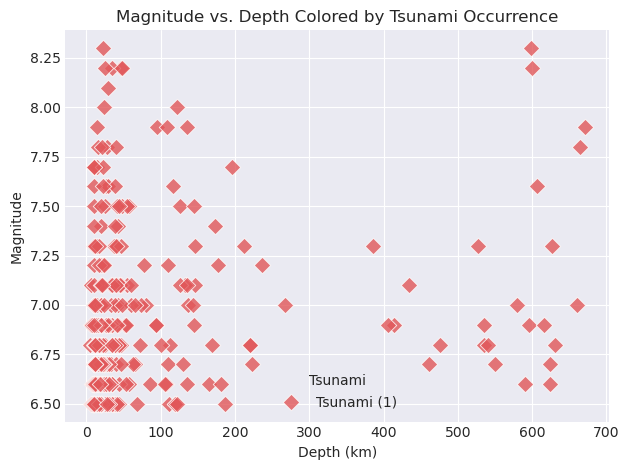

In [91]:
# Plot tsunami events (bolder color)
sns.scatterplot(
    x='depth',
    y='magnitude',
    data=df[df['tsunami'] == 1],
    color='#e15759',
    alpha=0.8,
    label='Tsunami (1)',
    s=70,
    marker='D' # Use a diamond marker for emphasis
)
plt.title('Magnitude vs. Depth Colored by Tsunami Occurrence')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.legend(title='Tsunami')
plt.tight_layout()
plt.show()


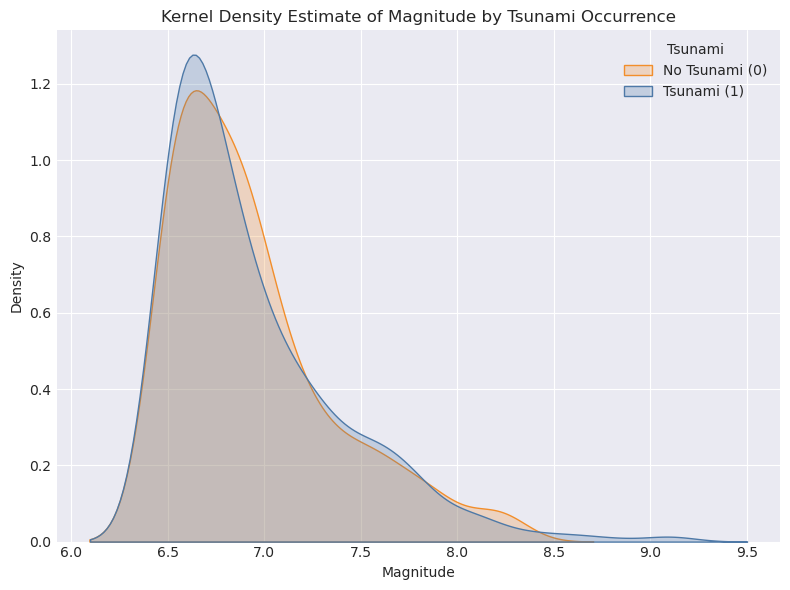

In [92]:
# 5. KDE Plot: Magnitude Distribution (NEW)
plt.figure(figsize=(8, 6))
# Remove common_norm for better comparison of shape
sns.kdeplot(data=df, x='magnitude', hue='tsunami', fill=True, common_norm=False, palette=['#4e79a7', '#f28e2b'])
plt.title('Kernel Density Estimate of Magnitude by Tsunami Occurrence')
plt.xlabel('Magnitude')
plt.ylabel('Density')
plt.legend(title='Tsunami', labels=['No Tsunami (0)', 'Tsunami (1)'])
plt.tight_layout()
plt.show()


# ML 

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc


In [94]:
# Feature Selection
features = ['magnitude', 'depth', 'latitude', 'longitude']
target = 'tsunami'

In [95]:
# Handle potential missing values (using median imputation as a robust choice)
for col in features:
    df[col].fillna(df[col].median(), inplace=True)

X = df[features]
y = df[target]

In [96]:
# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [97]:
# Define the list of classifiers to test
classifiers = {
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        random_state=42,
        class_weight='balanced' # Crucial for imbalanced data
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )
}


In [104]:
results = {}
y_probs = {}
# --- Pipeline Training and Evaluation Loop ---
print("--- Training and Evaluating Models with Pipeline ---")

for name, classifier in classifiers.items():
    print(f"\n--- Training {name} ---")

    # Create a pipeline: 1. Scale features, 2. Apply classifier
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', classifier)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_probs[name] = y_prob

    # Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate specific metrics needed for the report
    precision_tsunami = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_tsunami = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_tsunami = 2 * (precision_tsunami * recall_tsunami) / (precision_tsunami + recall_tsunami) if (precision_tsunami + recall_tsunami) > 0 else 0

    results[name] = {
        'AUC': roc_auc,
        'Accuracy': accuracy,
        'Precision': precision_tsunami,
        'Recall': recall_tsunami,
        'F1 Score': f1_tsunami
    }

    print(f"ROC AUC: {roc_auc:.4f}, Recall (Tsunami): {recall_tsunami:.4f}")


--- Training and Evaluating Models with Pipeline ---

--- Training Logistic Regression ---
ROC AUC: 0.5022, Recall (Tsunami): 0.3947

--- Training Random Forest ---
ROC AUC: 0.7275, Recall (Tsunami): 0.5132

--- Training Gradient Boosting ---
ROC AUC: 0.7297, Recall (Tsunami): 0.5132


In [105]:
# Feature Importance 
gb_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('classifier', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42))
])
gb_pipeline.fit(X_train, y_train)
gb_model = gb_pipeline.named_steps['classifier']

# Extract feature importance
feature_importance = pd.Series(gb_model.feature_importances_, index=features).sort_values(ascending=False)
feature_importance

longitude    0.630331
latitude     0.198560
depth        0.115112
magnitude    0.055997
dtype: float64

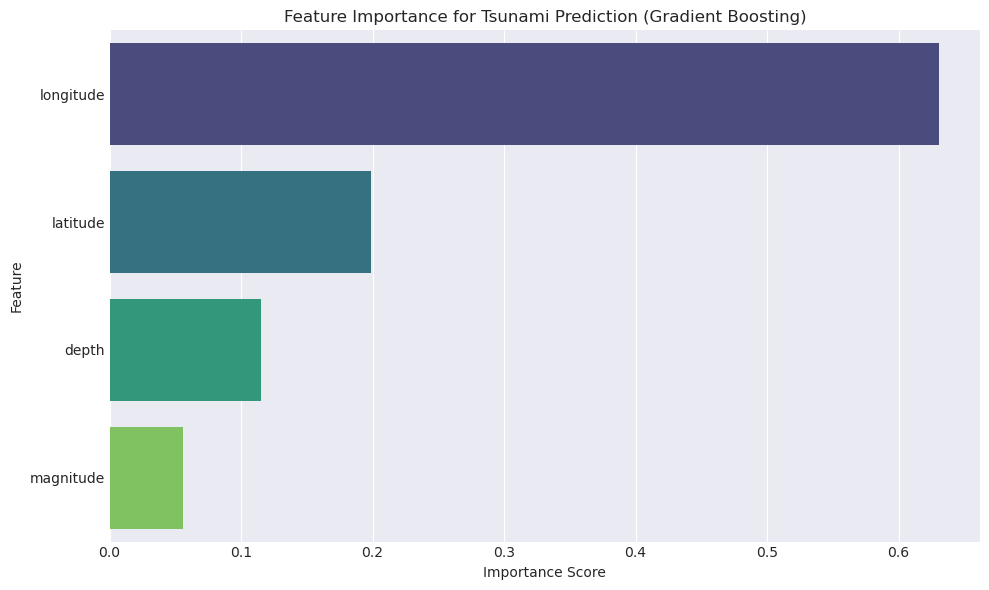

In [106]:
# --- Feature Importance Visualization ---
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance for Tsunami Prediction (Gradient Boosting)') # Updated Title
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()

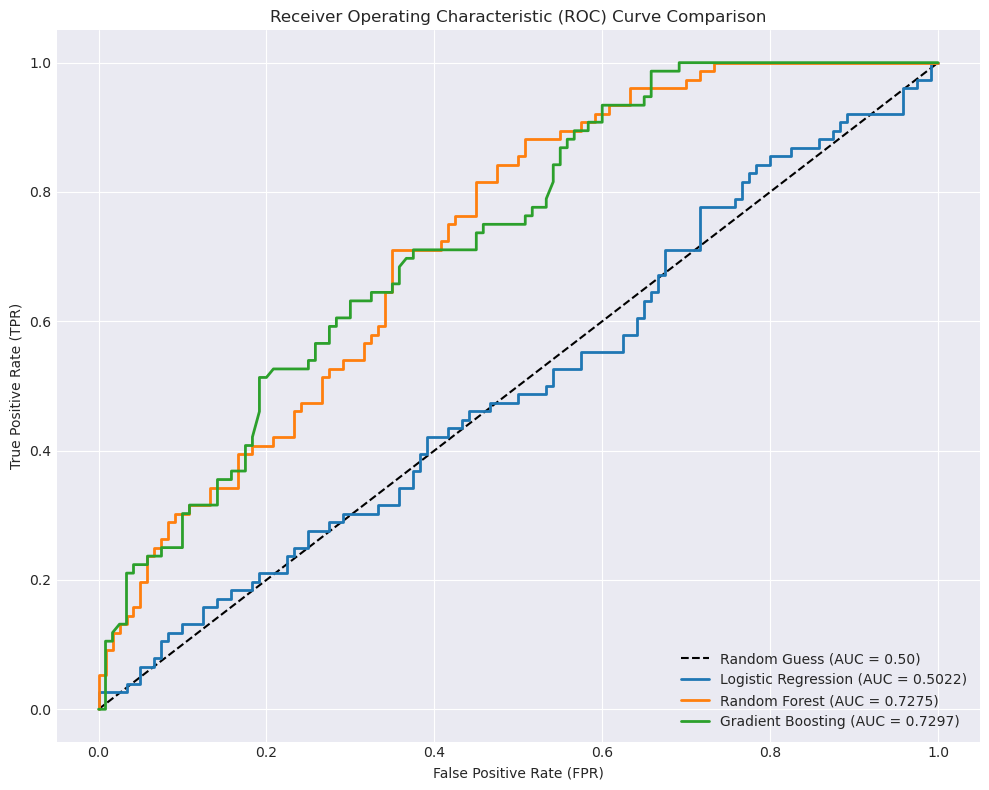

In [109]:
# --- ROC Curve Visualization (NEW) ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

for name, y_prob in y_probs.items():
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()


In [113]:
# Determine the best model based on F1 Score (best balance of precision and recall for the minority class)
results_df = pd.DataFrame(results).T
best_model_name = results_df['F1 Score'].idxmax()
best_model_metrics = results_df.loc[best_model_name]

print(f"\n--- BEST MODEL SUMMARY (Decision based on Tsunami F1 Score) ---")
print(f"Chosen Model: {best_model_name}")
print(f"  > AUC: {best_model_metrics['AUC']:.4f}")
print(f"  > Tsunami F1 Score: {best_model_metrics['F1 Score']:.4f}")
print(f"  > Tsunami Recall: {best_model_metrics['Recall']:.4f}")
print(f"----------------------------------------------------------")



--- BEST MODEL SUMMARY (Decision based on Tsunami F1 Score) ---
Chosen Model: Gradient Boosting
  > AUC: 0.7297
  > Tsunami F1 Score: 0.5612
  > Tsunami Recall: 0.5132
----------------------------------------------------------
